### Student Performance Analysis

In [4]:
# Importing libraries

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

# for better visuals
sns.set_style("whitegrid")

In [ ]:
# Load the Dataset
df= pd.read_csv("StudentsPerformance.csv")

In [ ]:
# Understand the Dataset (Basic Info)

df.head(5)   # Display first 5 rows

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
df.shape

(1000, 8)

In [8]:
df.dtypes

gender                           str
race/ethnicity                   str
parental level of education      str
lunch                            str
test preparation course          str
math score                     int64
reading score                  int64
writing score                  int64
dtype: object

In [9]:
df.info

<bound method DataFrame.info of      gender race/ethnicity parental level of education         lunch  \
0    female        group B           bachelor's degree      standard   
1    female        group C                some college      standard   
2    female        group B             master's degree      standard   
3      male        group A          associate's degree  free/reduced   
4      male        group C                some college      standard   
..      ...            ...                         ...           ...   
995  female        group E             master's degree      standard   
996    male        group C                 high school  free/reduced   
997  female        group C                 high school  free/reduced   
998  female        group D                some college      standard   
999  female        group D                some college  free/reduced   

    test preparation course  math score  reading score  writing score  
0                      none    

In [ ]:
# Check missing values

df.isnull().sum()

gender              0
race/ethnicity      0
parent_education    0
lunch               0
test_prep           0
math                0
reading             0
writing             0
dtype: int64

In [11]:
df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='str')

In [12]:

df.rename(columns={
    'math score': 'math',
    'reading score': 'reading',
    'writing score': 'writing',
    'parental level of education': 'parent_education',
    'test preparation course': 'test_prep'
}, inplace=True)

df.head()

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [16]:
df["average_score"]=(df["math"]+df["reading"]+df["writing"])

In [17]:
df.head()

,gender,race/ethnicity,parent_education,lunch,test_prep,math,reading,writing,average,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,218
1,female,group C,some college,standard,completed,69,90,88,247,247
2,female,group B,master's degree,standard,none,90,95,93,278,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,148
4,male,group C,some college,standard,none,76,78,75,229,229


In [27]:
df.groupby('gender')[['math', 'reading', 'writing', 'average_score']].mean()

,math,reading,writing,average_score
gender,,,,
female,63.633205,72.608108,72.467181,208.708494
male,68.728216,65.473029,63.311203,197.512448


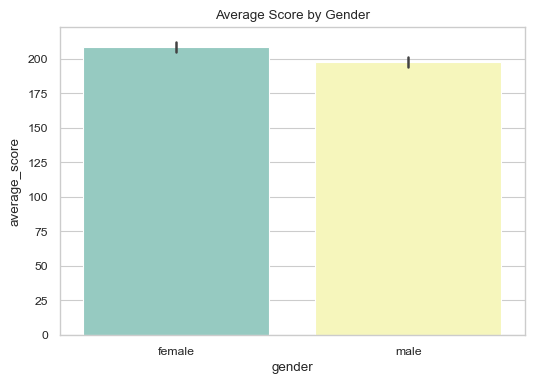

In [ ]:
# Gender vs Performance

plt.figure(figsize=(6,4))
sns.barplot( data=df,x='gender', y='average_score', hue="gender" ,palette="Set3")
plt.title("Average Score by Gender")
plt.show()

In [43]:
# Effect of Test Preparation

df.groupby('test_prep')['average_score'].mean()


test_prep
completed    218.008380
none         195.116822
Name: average_score, dtype: float64

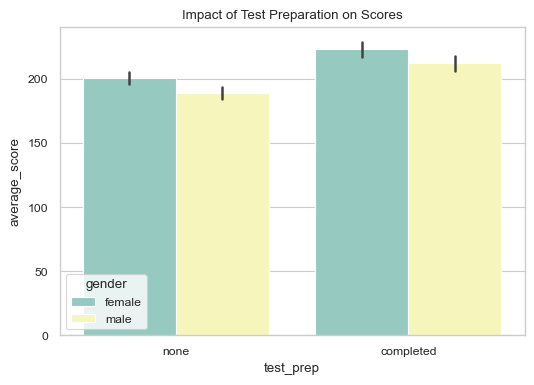

In [118]:
plt.figure(figsize=(6,4))
sns.set_context("paper")
plt.title("Impact of Test Preparation on Scores")
sns.barplot(data= df, x="test_prep", y="average_score",hue="gender", palette="Set3")
plt.show()

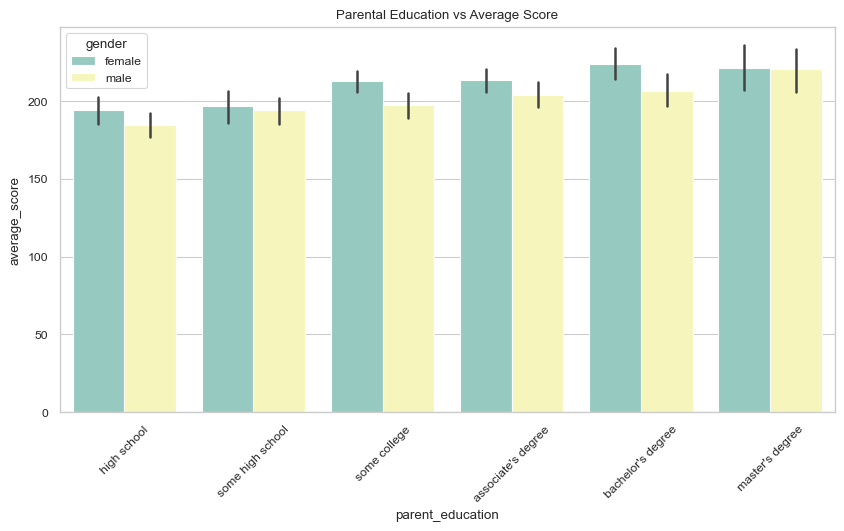

In [74]:
# Parental Education vs Scores

plt.figure(figsize=(10,5))
sns.barplot(
    data=df,
    x="parent_education",
    y="average_score",
    hue="gender",
    palette="Set3",
    order=df.groupby("parent_education")["average_score"].mean().sort_values().index
       )
plt.xticks(rotation=45)
plt.title("Parental Education vs Average Score")
plt.show()

In [75]:
# Lunch type vs Performance

df.groupby("lunch")["average_score"].mean()

lunch
free/reduced    186.597183
standard        212.511628
Name: average_score, dtype: float64

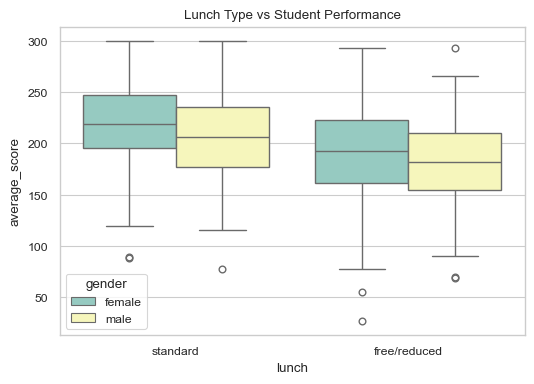

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x="lunch", y="average_score", hue="gender", palette="Set3")
plt.title("Lunch Type vs Student Performance")
plt.show()

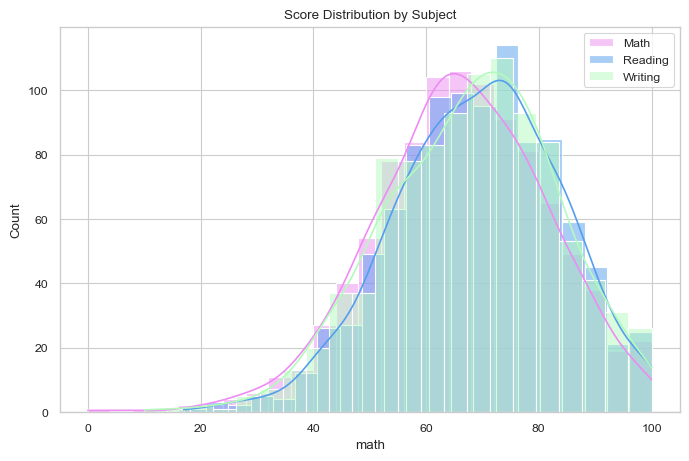

In [95]:
# Subject-wise Performance

plt.figure(figsize=(8,5))
sns.set_context("paper")
sns.histplot(data=df["math"], color="#ed8cf3", label= "Math" , kde=True)
sns.histplot(data=df["reading"], color="#549eed",label= "Reading",  kde=True)
sns.histplot(data=df["writing"], color="#b3fabd",label= "Writing",  kde=True)
plt.legend()
plt.title("Score Distribution by Subject")
plt.show()



In [109]:
# Correlation Analysis

df[['math', 'reading', 'writing', 'average_score']].corr()

,math,reading,writing,average_score
math,1.000000,0.817580,0.802642,0.918746
reading,0.817580,1.000000,0.954598,0.970331
writing,0.802642,0.954598,1.000000,0.965667
average_score,0.918746,0.970331,0.965667,1.000000


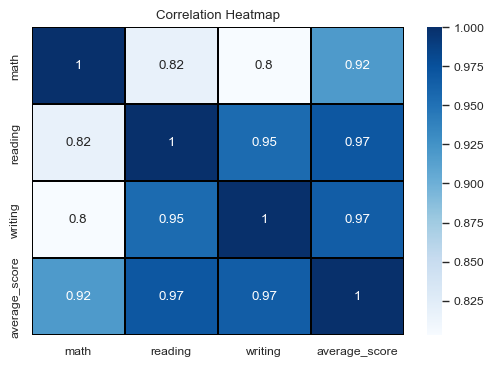

In [113]:
plt.figure(figsize=(6,4))
sns.heatmap(data = df[['math', 'reading', 'writing', 'average_score']].corr(),annot=True,cmap='Blues', linecolor="black", linewidths=0.2)
plt.title("Correlation Heatmap")
plt.show()

• Students who completed test preparation scored higher.

• Standard lunch students performed better on average.

• Reading scores are generally higher than math scores.

• Parental education has a positive impact on student performance.